In [1]:
import pandas as pd
import os

columns = ['unit', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1,4)] + \
          [f'sensor_{i}' for i in range(1,22)]

def load_dataset(dataset_name):
    
    base_path = r"C:\Users\prince\OneDrive\Desktop\CMaps"

    train_path = os.path.join(base_path, f"train_{dataset_name}.txt")
    test_path  = os.path.join(base_path, f"test_{dataset_name}.txt")
    rul_path   = os.path.join(base_path, f"RUL_{dataset_name}.txt")

    train = pd.read_csv(train_path, sep="\s+", header=None)
    train.columns = columns

    test = pd.read_csv(test_path, sep="\s+", header=None)
    test.columns = columns

    rul = pd.read_csv(rul_path, header=None)
    rul.columns = ["RUL"]

    return train, test, rul

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
C:\Users\prince\AppData\Local\Temp\ipykernel_5220\2949706305.py:16: SyntaxWarning: invalid escape sequence '\s'
  train = pd.read_csv(train_path, sep="\s+", header=None)
C:\Users\prince\AppData\Local\Temp\ipykernel_5220\2949706305.py:19: SyntaxWarning: invalid escape sequence '\s'
  test = pd.read_csv(test_path, sep="\s+", header=None)


In [2]:
train_FD001, test_FD001, rul_FD001 = load_dataset("FD001")
train_FD002, test_FD002, rul_FD002 = load_dataset("FD002")
train_FD003, test_FD003, rul_FD003 = load_dataset("FD003")
train_FD004, test_FD004, rul_FD004 = load_dataset("FD004")

print("FD001:", train_FD001.shape)
print("FD002:", train_FD002.shape)
print("FD003:", train_FD003.shape)
print("FD004:", train_FD004.shape)

FD001: (20631, 26)
FD002: (53759, 26)
FD003: (24720, 26)
FD004: (61249, 26)


In [3]:
def understand_data(train, name):
    print(f"\n{name} Dataset Info")
    print("Total Engines:", train['unit'].nunique())
    print("Total Cycles:", train['cycle'].max())
    print("Columns:", train.columns.tolist())
    
understand_data(train_FD001, "FD001")
understand_data(train_FD002, "FD002")
understand_data(train_FD003, "FD003")
understand_data(train_FD004, "FD004")


FD001 Dataset Info
Total Engines: 100
Total Cycles: 362
Columns: ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

FD002 Dataset Info
Total Engines: 260
Total Cycles: 378
Columns: ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

FD003 Dataset Info
Total Engines: 100
Total Cycles: 525
Columns: ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sen

In [4]:
from sklearn.preprocessing import StandardScaler

def preprocess(train):
    
    # Remove constant columns
    train = train.loc[:, train.std() != 0]
    
    features = train.drop(['unit','cycle'], axis=1)
    
    scaler = StandardScaler()
    scaled = scaler.fit_transform(features)
    
    scaled_df = pd.DataFrame(scaled, columns=features.columns)
    
    scaled_df['unit'] = train['unit']
    scaled_df['cycle'] = train['cycle']
    
    return train, scaled_df

In [5]:
def aggregate_engine(scaled_df):
    
    agg_df = scaled_df.groupby('unit').agg(['mean','std'])
    
    agg_df.columns = ['_'.join(col) for col in agg_df.columns]
    agg_df = agg_df.reset_index()
    
    return agg_df

In [6]:
from sklearn.decomposition import PCA

def apply_pca(agg_df):
    
    X = agg_df.drop('unit', axis=1)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    return X, X_pca

In [7]:
from sklearn.cluster import DBSCAN

def apply_dbscan(X_pca):
    
    db = DBSCAN(eps=2, min_samples=5)
    clusters = db.fit_predict(X_pca)
    
    return clusters

In [8]:
import matplotlib.pyplot as plt

def plot_clusters(X_pca, clusters, name):
    
    plt.figure(figsize=(6,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
    plt.title(f"{name} - DBSCAN Clusters")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar()
    plt.show()

In [9]:
from sklearn.ensemble import IsolationForest

def apply_isolation_forest(X):
    
    iso = IsolationForest(contamination=0.05, random_state=42)
    iso_labels = iso.fit_predict(X)
    
    return iso_labels

In [10]:
def early_warning(train):
    
    max_cycles = train.groupby('unit')['cycle'].max()
    threshold = max_cycles.quantile(0.25)
    
    early_units = max_cycles[max_cycles < threshold].index
    
    train['early_warning'] = train['unit'].isin(early_units).astype(int)
    
    return train, early_units

In [11]:
def run_pipeline(train, name):
    
    print(f"\nRunning Pipeline for {name}")
    
    # Preprocess
    train_clean, scaled_df = preprocess(train)
    
    # Aggregate
    agg_df = aggregate_engine(scaled_df)
    
    # PCA
    X, X_pca = apply_pca(agg_df)
    
    # DBSCAN
    clusters = apply_dbscan(X_pca)
    agg_df['DBSCAN'] = clusters
    
    # Isolation Forest
    iso_labels = apply_isolation_forest(X)
    agg_df['IsolationForest'] = iso_labels
    
    # Merge labels back
    train_final = train_clean.merge(
        agg_df[['unit','DBSCAN','IsolationForest']],
        on='unit',
        how='left'
    )
    
    # Early warning
    train_final, early_units = early_warning(train_final)
    
    # Plot
    plot_clusters(X_pca, clusters, name)
    
    print("Anomaly Engines (DBSCAN):", sum(clusters == -1))
    print("Anomaly Engines (IsolationForest):", sum(iso_labels == -1))
    print("Early Warning Engines:", len(early_units))
    
    return train_final, agg_df


Running Pipeline for FD001


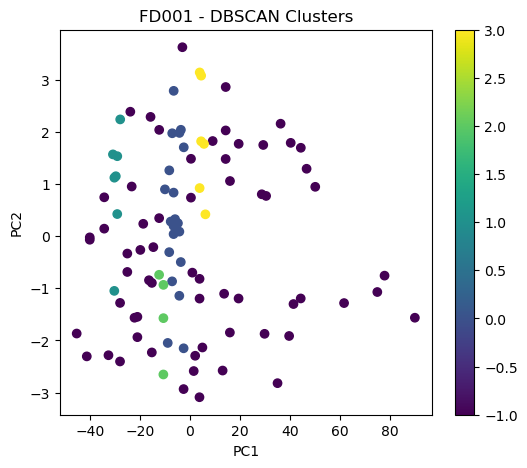

Anomaly Engines (DBSCAN): 63
Anomaly Engines (IsolationForest): 5
Early Warning Engines: 25

Running Pipeline for FD002


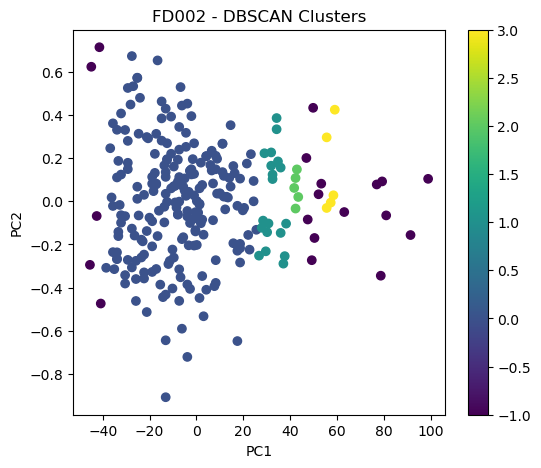

Anomaly Engines (DBSCAN): 19
Anomaly Engines (IsolationForest): 13
Early Warning Engines: 62

Running Pipeline for FD003


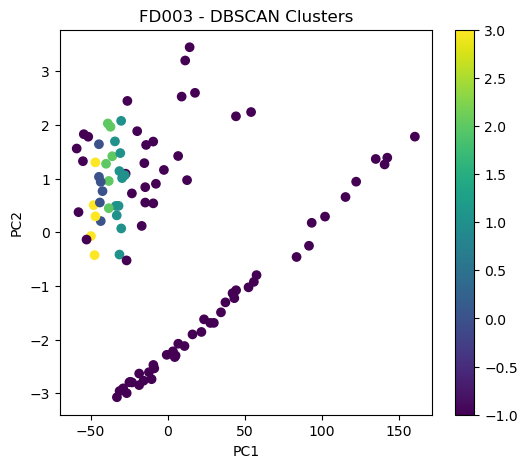

Anomaly Engines (DBSCAN): 72
Anomaly Engines (IsolationForest): 5
Early Warning Engines: 25

Running Pipeline for FD004


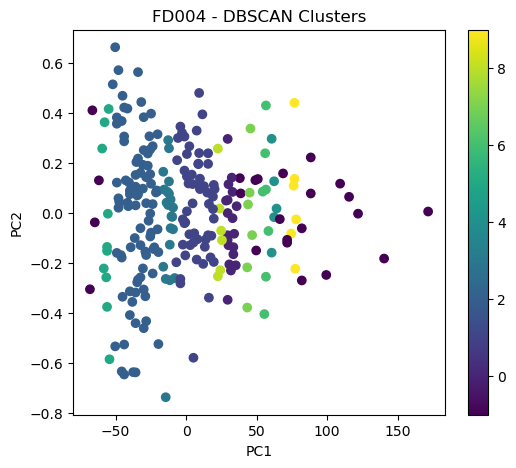

Anomaly Engines (DBSCAN): 23
Anomaly Engines (IsolationForest): 13
Early Warning Engines: 62


In [12]:
fd001_result, fd001_agg = run_pipeline(train_FD001, "FD001")
fd002_result, fd002_agg = run_pipeline(train_FD002, "FD002")
fd003_result, fd003_agg = run_pipeline(train_FD003, "FD003")
fd004_result, fd004_agg = run_pipeline(train_FD004, "FD004")